Memory-Efficient Smart Energy Data Stream Analytics Using Bloom Filter and Flajolet–Martin Algorithm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import time
import sys

In [2]:
!wget -q https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip

!unzip -o -q individual+household+electric+power+consumption.zip

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values="?"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB
None

Missing Values:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [5]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [6]:
numeric_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)

print("Records after cleaning:", len(df))

Records after cleaning: 2049280


In [7]:
df["Timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

df = df.sort_values("Timestamp")

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Timestamp
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [8]:
df["Power_State"] = df["Global_active_power"].round(1)
df["Voltage_State"] = df["Voltage"].round(0)

df["Energy_State"] = (
    df["Power_State"].astype(str)
    + "_"
    + df["Voltage_State"].astype(str)
)

stream = df["Energy_State"].tolist()

print("Total stream elements:", len(stream))
print("Exact unique energy states:", len(set(stream)))

print("\nSample states:")
print(stream[:10])

Total stream elements: 2049280
Exact unique energy states: 1926

Sample states:
['4.2_235.0', '5.4_234.0', '5.4_233.0', '5.4_234.0', '3.7_236.0', '3.5_235.0', '3.7_235.0', '3.7_235.0', '3.7_234.0', '3.7_234.0']


In [9]:
class BloomFilter:

    def __init__(self, size=500000, hash_count=5):

        self.size = size
        self.hash_count = hash_count
        self.bit_array = bytearray(size)

    def _hashes(self, item):

        indexes = []

        for seed in range(self.hash_count):

            value = f"{seed}-{item}"

            digest = hashlib.sha256(
                value.encode()
            ).hexdigest()

            index = int(digest, 16) % self.size

            indexes.append(index)

        return indexes


    def add(self, item):

        for index in self._hashes(item):
            self.bit_array[index] = 1


    def contains(self, item):

        return all(
            self.bit_array[index] == 1
            for index in self._hashes(item)
        )

In [10]:
test_stream = stream[:500000]

bloom = BloomFilter(
    size=500000,
    hash_count=5
)

exact_seen = set()

false_positives = 0
new_elements = 0

start = time.time()

for item in test_stream:

    bloom_result = bloom.contains(item)

    actual_result = item in exact_seen

    if not actual_result:

        new_elements += 1

        if bloom_result:
            false_positives += 1

    bloom.add(item)

    exact_seen.add(item)

end = time.time()

In [11]:
fp_rate = (
    false_positives / new_elements
) * 100

print("Stream Size:", len(test_stream))
print("Unique Energy States:", len(exact_seen))

print(
    "Bloom Filter False Positives:",
    false_positives
)

print(
    f"False Positive Rate: {fp_rate:.4f}%"
)

print(
    f"Processing Time: {end-start:.2f} seconds"
)

Stream Size: 500000
Unique Energy States: 1523
Bloom Filter False Positives: 0
False Positive Rate: 0.0000%
Processing Time: 9.49 seconds


In [12]:
def trailing_zeros(number):

    if number == 0:
        return 256

    count = 0

    while (number & 1) == 0:

        count += 1
        number >>= 1

    return count

In [13]:
def flajolet_martin(stream, num_hashes=32):

    estimates = []

    for seed in range(num_hashes):

        max_zero = 0

        for item in stream:

            value = f"{seed}-{item}"

            digest = hashlib.sha256(
                value.encode()
            ).digest()

            hashed_value = int.from_bytes(
                digest,
                byteorder="big"
            )

            zeros = trailing_zeros(
                hashed_value
            )

            max_zero = max(
                max_zero,
                zeros
            )

        estimates.append(
            2 ** max_zero
        )

    return np.median(estimates)

In [14]:
fm_stream = stream[:100000]

actual_unique = len(
    set(fm_stream)
)

start = time.time()

fm_estimate = flajolet_martin(
    fm_stream,
    num_hashes=16
)

end = time.time()

error = (
    abs(fm_estimate - actual_unique)
    / actual_unique
) * 100

print(
    "Actual Distinct Energy States:",
    actual_unique
)

print(
    "FM Estimated States:",
    int(fm_estimate)
)

print(
    f"Estimation Error: {error:.2f}%"
)

print(
    f"Execution Time: {end-start:.2f}s"
)

Actual Distinct Energy States: 1219
FM Estimated States: 1024
Estimation Error: 16.00%
Execution Time: 3.19s


In [15]:
stream_sizes = [
    10000,
    25000,
    50000,
    75000,
    100000
]

results = []

for size in stream_sizes:

    current_stream = stream[:size]

    actual = len(
        set(current_stream)
    )

    estimated = flajolet_martin(
        current_stream,
        num_hashes=16
    )

    error = (
        abs(estimated - actual)
        / actual
    ) * 100

    results.append(
        [
            size,
            actual,
            int(estimated),
            error
        ]
    )

In [16]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Stream Size",
        "Actual Distinct",
        "FM Estimate",
        "Error (%)"
    ]
)

results_df

,Stream Size,Actual Distinct,FM Estimate,Error (%)
0,10000,674,1024,51.928783
1,25000,991,1024,3.329970
2,50000,1104,1024,7.246377
3,75000,1177,1024,12.999150
4,100000,1219,1024,15.996719


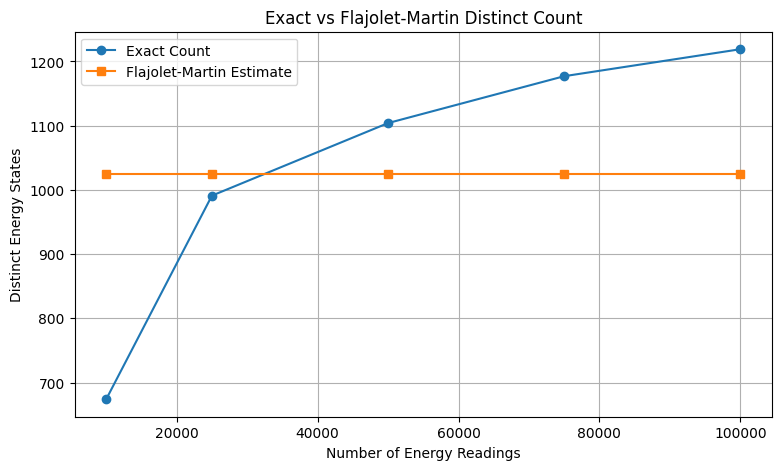

In [17]:
plt.figure(figsize=(9,5))

plt.plot(
    results_df["Stream Size"],
    results_df["Actual Distinct"],
    marker="o",
    label="Exact Count"
)

plt.plot(
    results_df["Stream Size"],
    results_df["FM Estimate"],
    marker="s",
    label="Flajolet-Martin Estimate"
)

plt.xlabel("Number of Energy Readings")
plt.ylabel("Distinct Energy States")

plt.title(
    "Exact vs Flajolet-Martin Distinct Count"
)

plt.legend()
plt.grid()

plt.show()

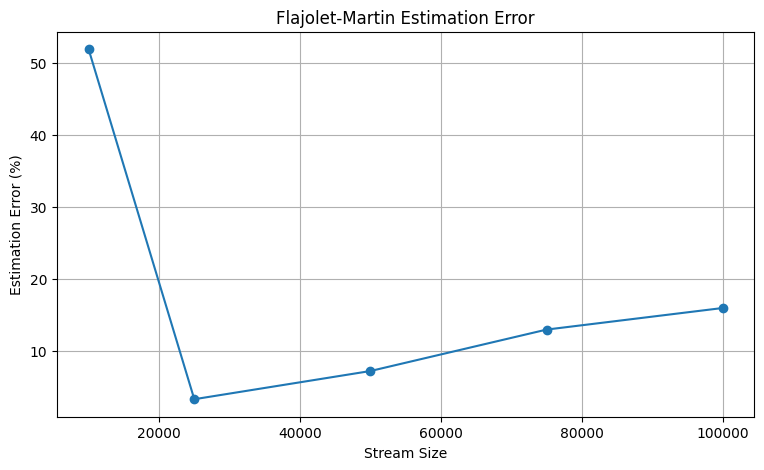

In [18]:
plt.figure(figsize=(9,5))

plt.plot(
    results_df["Stream Size"],
    results_df["Error (%)"],
    marker="o"
)

plt.xlabel("Stream Size")
plt.ylabel("Estimation Error (%)")

plt.title(
    "Flajolet-Martin Estimation Error"
)

plt.grid()

plt.show()

In [19]:
filter_sizes = [
    10000,
    25000,
    50000,
    100000,
    200000
]

fp_rates = []

sample_stream = stream[:100000]

for filter_size in filter_sizes:

    bloom = BloomFilter(
        size=filter_size,
        hash_count=5
    )

    exact = set()

    false_positive = 0
    new_items = 0

    for item in sample_stream:

        bloom_seen = bloom.contains(item)

        actually_seen = item in exact

        if not actually_seen:

            new_items += 1

            if bloom_seen:
                false_positive += 1

        bloom.add(item)
        exact.add(item)

    rate = (
        false_positive
        / new_items
    ) * 100

    fp_rates.append(rate)

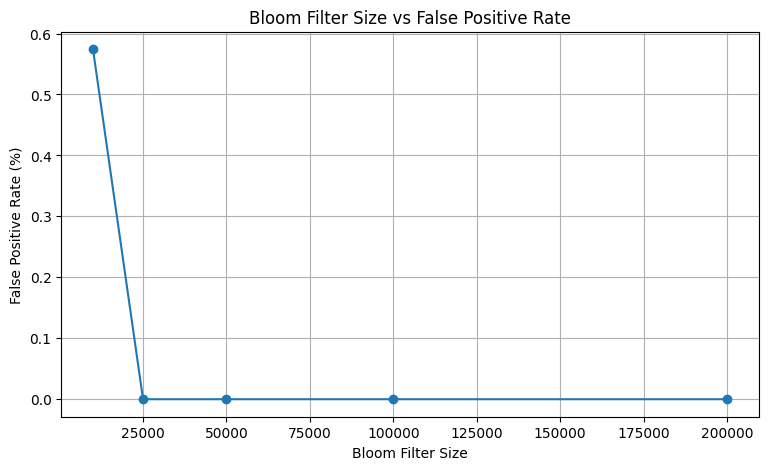

In [20]:
plt.figure(figsize=(9,5))

plt.plot(
    filter_sizes,
    fp_rates,
    marker="o"
)

plt.xlabel("Bloom Filter Size")
plt.ylabel("False Positive Rate (%)")

plt.title(
    "Bloom Filter Size vs False Positive Rate"
)

plt.grid()

plt.show()

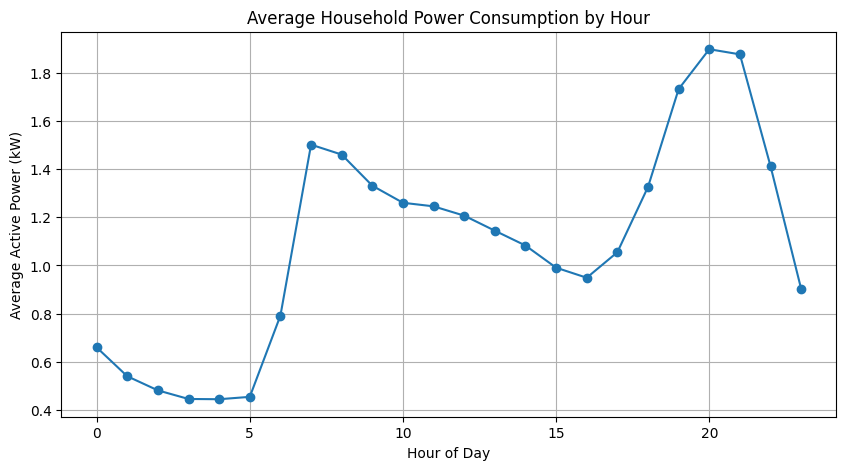

In [21]:
df["Hour"] = df["Timestamp"].dt.hour

hourly_power = (
    df.groupby("Hour")
      ["Global_active_power"]
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    hourly_power.index,
    hourly_power.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Active Power (kW)")

plt.title(
    "Average Household Power Consumption by Hour"
)

plt.grid()

plt.show()